# Tenerife

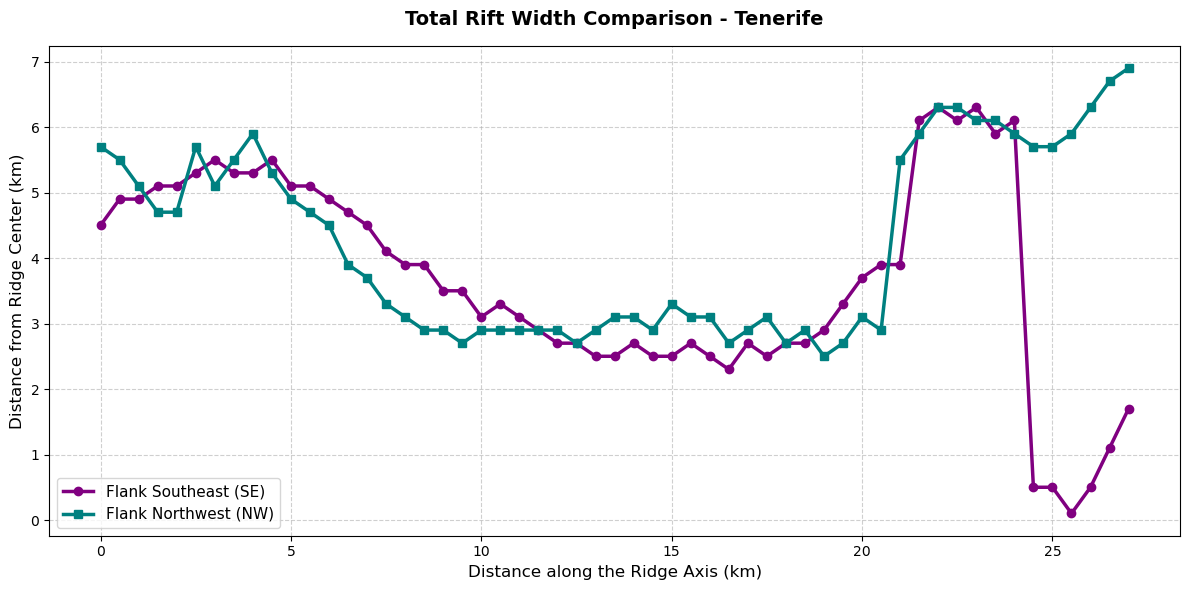

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# =============================================================================
# CONFIGURATION PANEL (Tenerife Specific Configuration)
# =============================================================================
# File path
T_CSV_PATH = "Gradient_Tenerife.csv"

T_ISLAND = "Tenerife"

# Column Names in your CSV
T_COL_ALONG_RIDGE = "distance"       # Acts as BOTH profile ID and X-axis position (0, 500, 1000...)
T_COL_VERTEX_IDX = "vertex_index"    # Tracking points along the cross-profile (0 to 101)
T_COL_GRADIENT = "gradient"          # The measured maximum gradient values

# Side Boundaries (Vertex index ranges)
# Side 1 (Southeast)
T_SIDE_1_NAME = "Southeast (SE)"
T_SIDE_1_MIN_IDX = 0                 # First point index on this side
T_SIDE_1_MAX_IDX = 50                # Last point index on this side
T_COLOR_SIDE_1 = "purple"            # Plot color for Side 1

# Side 2 (Northwest)
T_SIDE_2_NAME = "Northwest (NW)"
T_SIDE_2_MIN_IDX = 51
T_SIDE_2_MAX_IDX = 101
T_COLOR_SIDE_2 = "teal"              # Plot color for Side 2

# Geometry Conversions (Distance from center in meters)
T_RIDGE_CENTER_M = 10100             # Ridge center
T_POINT_SPACING_M = 200              # Distance between profile points

def T_calc_distance_side_1(vertex_idx):
    """Formula for Southeast side: 10100 - (index * 200)"""
    return T_RIDGE_CENTER_M - (vertex_idx * T_POINT_SPACING_M)

def T_calc_distance_side_2(vertex_idx):
    """Formula for Northwest side: (index * 200) - 10100"""
    return (vertex_idx * T_POINT_SPACING_M) - T_RIDGE_CENTER_M

# =============================================================================
# DATA PROCESSING ENGINE
# =============================================================================

# 1. Load the data
T_df = pd.read_csv(T_CSV_PATH)

# Lists to store our final plotting data
T_along_ridge_x = []
T_side_1_y = []
T_side_2_y = []

# 2. Group directly by the distance along the ridge (since 0, 500, 1000 isolate each profile)
T_grouped = T_df.groupby(T_COL_ALONG_RIDGE)

for T_x_val, T_group in T_grouped:
    # Save the current profile's X position
    T_along_ridge_x.append(T_x_val)
    
    # --- SIDE 1 (Southeast) ---
    # Filter for SE indices
    T_side_1_filter = (T_group[T_COL_VERTEX_IDX] >= T_SIDE_1_MIN_IDX) & (T_group[T_COL_VERTEX_IDX] <= T_SIDE_1_MAX_IDX)
    T_group_side_1 = T_group[T_side_1_filter]
    
    if not T_group_side_1.empty:
        # Find the row index where the gradient is absolute maximum
        T_max_row_idx_1 = T_group_side_1[T_COL_GRADIENT].idxmax()
        T_max_vertex_1 = T_group_side_1.loc[T_max_row_idx_1, T_COL_VERTEX_IDX]
        # Convert vertex index to distance from center
        T_y_val_1 = T_calc_distance_side_1(T_max_vertex_1)
        T_side_1_y.append(T_y_val_1)
    else:
        T_side_1_y.append(None)

    # --- SIDE 2 (Northwest) ---
    # Filter for NW indices
    T_side_2_filter = (T_group[T_COL_VERTEX_IDX] >= T_SIDE_2_MIN_IDX) & (T_group[T_COL_VERTEX_IDX] <= T_SIDE_2_MAX_IDX)
    T_group_side_2 = T_group[T_side_2_filter]
    
    if not T_group_side_2.empty:
        # Find the row index where the gradient is absolute maximum
        T_max_row_idx_2 = T_group_side_2[T_COL_GRADIENT].idxmax()
        T_max_vertex_2 = T_group_side_2.loc[T_max_row_idx_2, T_COL_VERTEX_IDX]
        # Convert vertex index to distance from center
        T_y_val_2 = T_calc_distance_side_2(T_max_vertex_2)
        T_side_2_y.append(T_y_val_2)
    else:
        T_side_2_y.append(None)

# Create a clean dataframe for final results
T_results_df = pd.DataFrame({
    'Along_Ridge_X': T_along_ridge_x,
    'Side_1_Y': T_side_1_y,
    'Side_2_Y': T_side_2_y
}).sort_values(by='Along_Ridge_X') # Kept in order from 0 to max distance

# =============================================================================
# PLOTTING (Unified Single Plot)
# =============================================================================
plt.figure(figsize=(12, 6))

# Convert the X axis (along ridge) and Y axis data into kilometers for clearer visualization
T_x_in_km = T_results_df['Along_Ridge_X'] / 1000

# 1. Plot line for the Southeast (SE) flank
plt.plot(T_x_in_km, T_results_df['Side_1_Y'] / 1000, 
         color=T_COLOR_SIDE_1, marker='o', linestyle='-', linewidth=2.5, 
         label=f"Flank {T_SIDE_1_NAME}")

# 2. Plot line for the Northwest (NW) flank
plt.plot(T_x_in_km, T_results_df['Side_2_Y'] / 1000, 
         color=T_COLOR_SIDE_2, marker='s', linestyle='-', linewidth=2.5, 
         label=f"Flank {T_SIDE_2_NAME}")

# Labels, title, and layout configurations
plt.title(f"Total Rift Width Comparison - {T_ISLAND}", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Distance along the Ridge Axis (km)", fontsize=12)
plt.ylabel("Distance from Ridge Center (km)", fontsize=12)

# Grid setup and legend mapping
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11, loc='lower left')

plt.tight_layout()
plt.savefig(f"2Sides_Total_Rift_Width_{T_ISLAND}.png", dpi=300, bbox_inches='tight')
plt.show()

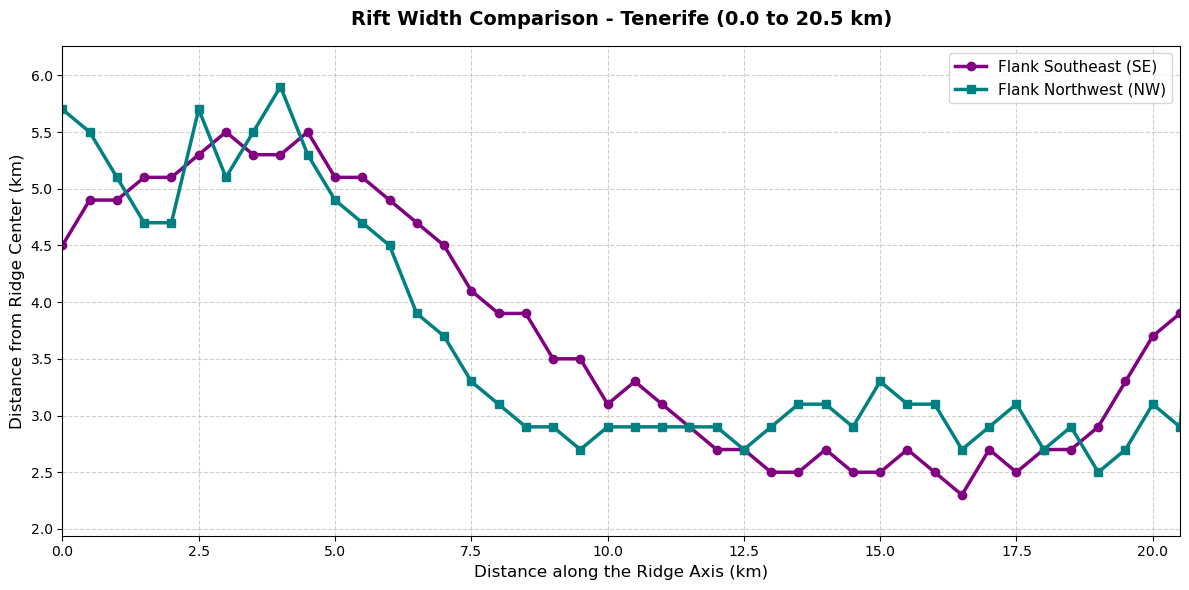

In [2]:
# =============================================================================
# CONFIGURATION PANEL: ZOOM & DESIGN (Modify as needed)
# =============================================================================
T_START_DIST_KM = 0.0   # Start of the focus area along the ridge (X-axis)
T_END_DIST_KM = 20.5    # End of the focus area along the ridge (X-axis)

# =============================================================================
# SINGLE PLOT ZOOMED COMPARISON ENGINE
# =============================================================================
plt.figure(figsize=(12, 6))

# 1. Plot line for the Southeast (SE) flank
plt.plot(T_x_in_km, T_results_df['Side_1_Y'] / 1000, 
         color=T_COLOR_SIDE_1, marker='o', linestyle='-', linewidth=2.5, 
         label=f"Flank {T_SIDE_1_NAME}")

# 2. Plot line for the Northwest (NW) flank
plt.plot(T_x_in_km, T_results_df['Side_2_Y'] / 1000, 
         color=T_COLOR_SIDE_2, marker='s', linestyle='-', linewidth=2.5, 
         label=f"Flank {T_SIDE_2_NAME}")

# Graphical customization, titles, and labels
plt.title(f"Rift Width Comparison - {T_ISLAND} ({T_START_DIST_KM} to {T_END_DIST_KM} km)", 
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Distance along the Ridge Axis (km)", fontsize=12)
plt.ylabel("Distance from Ridge Center (km)", fontsize=12)

# Set horizontal zoom limits
plt.xlim(T_START_DIST_KM, T_END_DIST_KM)

# Force Y-axis to dynamically auto-scale based ONLY on the visible zoomed data
# Filter rows matching the zoom window to calculate local min/max values
T_visible_data = T_results_df[(T_x_in_km >= T_START_DIST_KM) & (T_x_in_km <= T_END_DIST_KM)]
if not T_visible_data.empty:
    # Combine values from both sides to find total min and max bounds
    T_combined_y = pd.concat([T_visible_data['Side_1_Y'], T_visible_data['Side_2_Y']]) / 1000
    T_y_min, T_y_max = T_combined_y.min(), T_combined_y.max()
    
    # Add a small 10% padding buffer so points don't clip against edges
    T_padding = (T_y_max - T_y_min) * 0.1 if T_y_max != T_y_min else 1.0
    plt.ylim(T_y_min - T_padding, T_y_max + T_padding)

# Grid setup and legend placement
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11, loc='upper right')

plt.tight_layout()
plt.savefig(f"2Sides_Rift_Width_{T_ISLAND}.png", dpi=300, bbox_inches='tight')
plt.show()

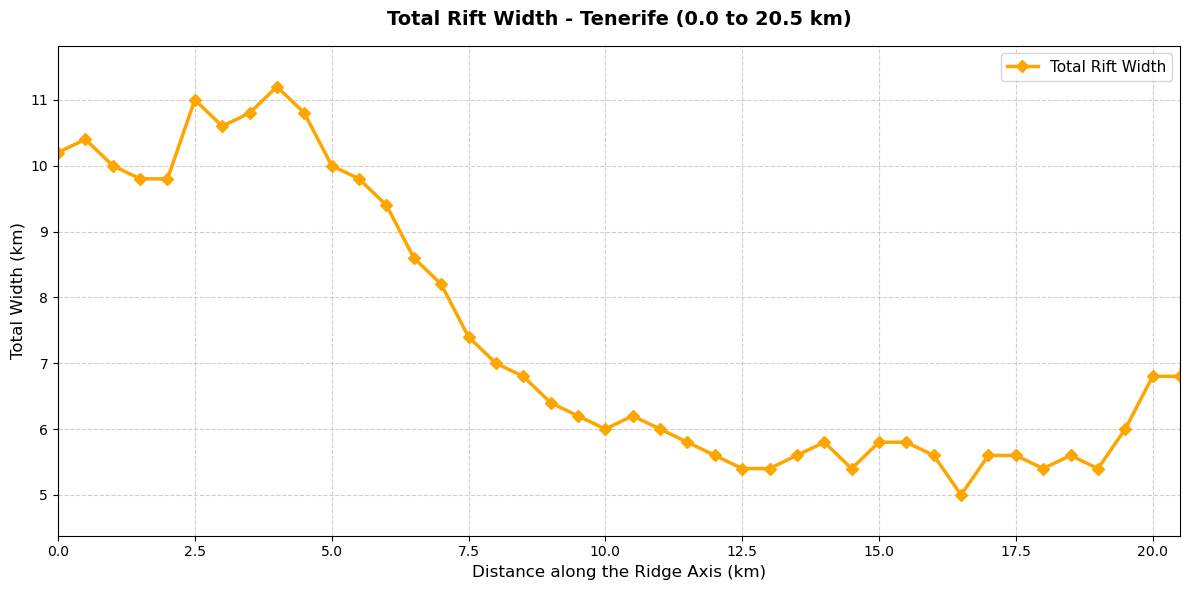

In [3]:
# =============================================================================
# CONFIGURATION PANEL: ZOOM & DESIGN (Modify as needed)
# =============================================================================
T_COLOR_TOTAL_WIDTH = "orange" # Plot color for the total width line

# =============================================================================
# TOTAL WIDTH PLOT ENGINE
# =============================================================================
plt.figure(figsize=(12, 6))

# Calculate the Total Rift Width by adding both sides together (converted to km)
# Note: Since both Side_1_Y and Side_2_Y represent absolute distances from the center,
# we simply add them together.
T_total_width_km = (T_results_df['Side_1_Y'] + T_results_df['Side_2_Y']) / 1000

# Plot line for the Total Rift Width
plt.plot(T_x_in_km, T_total_width_km, 
         color=T_COLOR_TOTAL_WIDTH, marker='D', linestyle='-', linewidth=2.5, 
         label="Total Rift Width")

# Graphical customization, titles, and labels
plt.title(f"Total Rift Width - {T_ISLAND} ({T_START_DIST_KM} to {T_END_DIST_KM} km)", 
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Distance along the Ridge Axis (km)", fontsize=12)
plt.ylabel("Total Width (km)", fontsize=12)

# Set horizontal zoom limits
plt.xlim(T_START_DIST_KM, T_END_DIST_KM)

# Force Y-axis to dynamically auto-scale based ONLY on the visible zoomed data
T_visible_data_total = T_results_df[(T_x_in_km >= T_START_DIST_KM) & (T_x_in_km <= T_END_DIST_KM)]
if not T_visible_data_total.empty:
    # Calculate local min/max for the total width inside the zoom window
    T_visible_total_width = (T_visible_data_total['Side_1_Y'] + T_visible_data_total['Side_2_Y']) / 1000
    T_y_min_total, T_y_max_total = T_visible_total_width.min(), T_visible_total_width.max()
    
    # Add a small 10% padding buffer so points don't clip against edges
    T_padding_total = (T_y_max_total - T_y_min_total) * 0.1 if T_y_max_total != T_y_min_total else 1.0
    plt.ylim(T_y_min_total - T_padding_total, T_y_max_total + T_padding_total)

# Grid setup and legend placement
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11, loc='upper right')

plt.tight_layout()
plt.savefig(f"Rift_Width_{T_ISLAND}.png", dpi=300, bbox_inches='tight')
plt.show()

# Kilauea

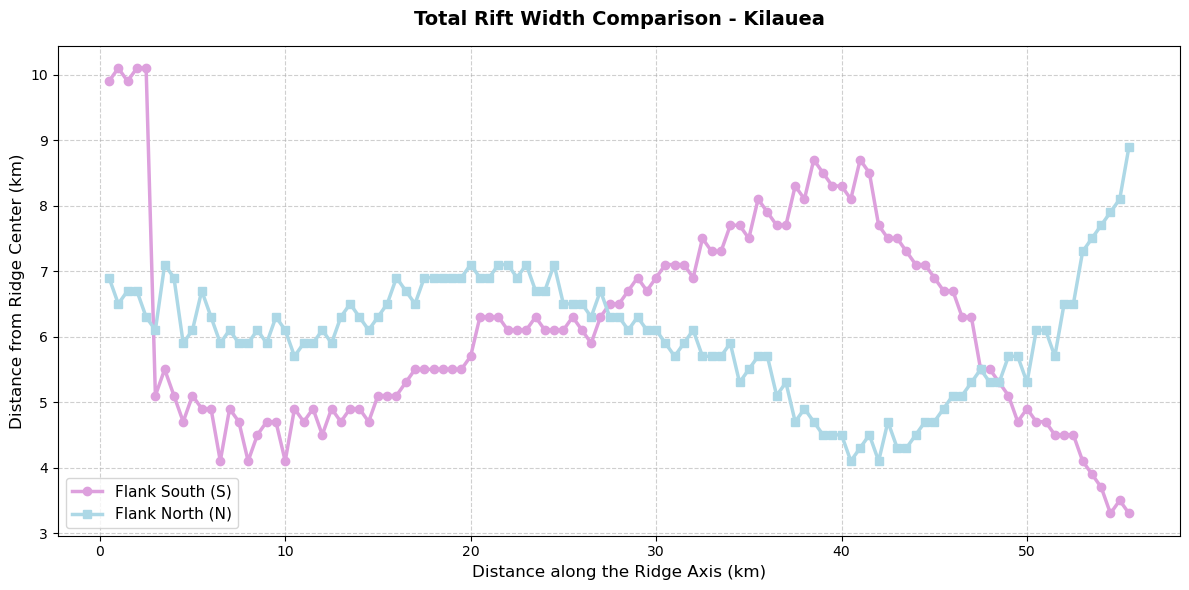

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# =============================================================================
# CONFIGURATION PANEL (Kilauea Specific Configuration)
# =============================================================================
# File path
K_CSV_PATH = "Gradient_Kilauea.csv"

K_ISLAND = "Kilauea"

# Column Names in your CSV
K_COL_ALONG_RIDGE = "distance"       # Acts as BOTH profile ID and X-axis position (0, 500, 1000...)
K_COL_VERTEX_IDX = "vertex_index"    # Tracking points along the cross-profile (0 to 101)
K_COL_GRADIENT = "gradient"          # The measured maximum gradient values

# Side Boundaries (Vertex index ranges)
# Side 1 (South)
K_SIDE_1_NAME = "South (S)"
K_SIDE_1_MIN_IDX = 0                 # First point index on this side
K_SIDE_1_MAX_IDX = 50                # Last point index on this side
K_COLOR_SIDE_1 = "plum"           # Plot color for Side 1

# Side 2 (North)
K_SIDE_2_NAME = "North (N)"
K_SIDE_2_MIN_IDX = 51
K_SIDE_2_MAX_IDX = 101
K_COLOR_SIDE_2 = "lightblue"              # Plot color for Side 2

# Geometry Conversions (Distance from center in meters)
K_RIDGE_CENTER_M = 10100             # Ridge center
K_POINT_SPACING_M = 200              # Distance between profile points

def K_calc_distance_side_1(vertex_idx):
    """Formula for Side 1: 10100 - (index * 200)"""
    return K_RIDGE_CENTER_M - (vertex_idx * K_POINT_SPACING_M)

def K_calc_distance_side_2(vertex_idx):
    """Formula for Side 2: (index * 200) - 10100"""
    return (vertex_idx * K_POINT_SPACING_M) - K_RIDGE_CENTER_M

# =============================================================================
# DATA PROCESSING ENGINE
# =============================================================================

# 1. Load the data
K_df = pd.read_csv(K_CSV_PATH)

# Lists to store our final plotting data
K_along_ridge_x = []
K_side_1_y = []
K_side_2_y = []

# 2. Group directly by the distance along the ridge (since 0, 500, 1000 isolate each profile)
K_grouped = K_df.groupby(K_COL_ALONG_RIDGE)

for K_x_val, K_group in K_grouped:
    # Save the current profile's X position
    K_along_ridge_x.append(K_x_val)
    
    # --- SIDE 1 ---
    # Filter for Side 1 indices
    K_side_1_filter = (K_group[K_COL_VERTEX_IDX] >= K_SIDE_1_MIN_IDX) & (K_group[K_COL_VERTEX_IDX] <= K_SIDE_1_MAX_IDX)
    K_group_side_1 = K_group[K_side_1_filter]
    
    if not K_group_side_1.empty:
        # Find the row index where the gradient is absolute maximum
        K_max_row_idx_1 = K_group_side_1[K_COL_GRADIENT].idxmax()
        K_max_vertex_1 = K_group_side_1.loc[K_max_row_idx_1, K_COL_VERTEX_IDX]
        # Convert vertex index to distance from center
        K_y_val_1 = K_calc_distance_side_1(K_max_vertex_1)
        K_side_1_y.append(K_y_val_1)
    else:
        K_side_1_y.append(None)

    # --- SIDE 2 ---
    # Filter for Side 2 indices
    K_side_2_filter = (K_group[K_COL_VERTEX_IDX] >= K_SIDE_2_MIN_IDX) & (K_group[K_COL_VERTEX_IDX] <= K_SIDE_2_MAX_IDX)
    K_group_side_2 = K_group[K_side_2_filter]
    
    if not K_group_side_2.empty:
        # Find the row index where the gradient is absolute maximum
        K_max_row_idx_2 = K_group_side_2[K_COL_GRADIENT].idxmax()
        K_max_vertex_2 = K_group_side_2.loc[K_max_row_idx_2, K_COL_VERTEX_IDX]
        # Convert vertex index to distance from center
        K_y_val_2 = K_calc_distance_side_2(K_max_vertex_2)
        K_side_2_y.append(K_y_val_2)
    else:
        K_side_2_y.append(None)

# Create a clean dataframe for final results
K_results_df = pd.DataFrame({
    'Along_Ridge_X': K_along_ridge_x,
    'Side_1_Y': K_side_1_y,
    'Side_2_Y': K_side_2_y
}).sort_values(by='Along_Ridge_X') # Kept in order from 0 to max distance

# =============================================================================
# PLOTTING (Unified Single Plot)
# =============================================================================
plt.figure(figsize=(12, 6))

# Convert the X axis (along ridge) and Y axis data into kilometers for clearer visualization
K_x_in_km = K_results_df['Along_Ridge_X'] / 1000

# 1. Plot line for the Side 1 flank
plt.plot(K_x_in_km, K_results_df['Side_1_Y'] / 1000, 
         color=K_COLOR_SIDE_1, marker='o', linestyle='-', linewidth=2.5, 
         label=f"Flank {K_SIDE_1_NAME}")

# 2. Plot line for the Side 2 flank
plt.plot(K_x_in_km, K_results_df['Side_2_Y'] / 1000, 
         color=K_COLOR_SIDE_2, marker='s', linestyle='-', linewidth=2.5, 
         label=f"Flank {K_SIDE_2_NAME}")

# Labels, title, and layout configurations
plt.title(f"Total Rift Width Comparison - {K_ISLAND}", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Distance along the Ridge Axis (km)", fontsize=12)
plt.ylabel("Distance from Ridge Center (km)", fontsize=12)

# Grid setup and legend mapping
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11, loc='lower left')

plt.tight_layout()
plt.savefig(f"2Sides_Total_Rift_Width_{K_ISLAND}.png", dpi=300, bbox_inches='tight')
plt.show()

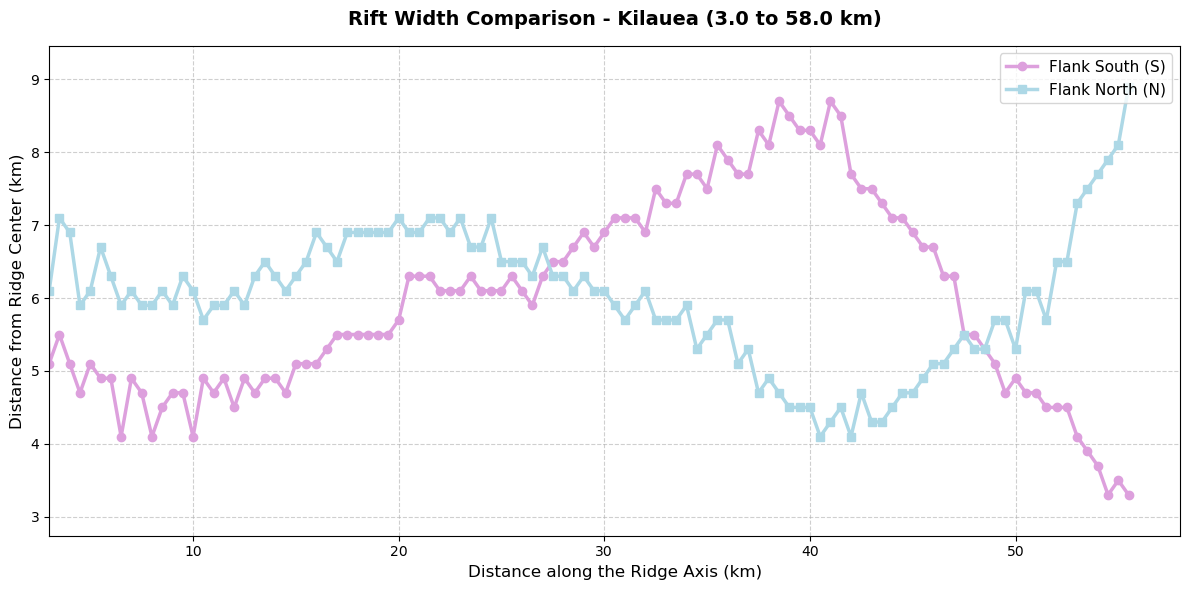

In [5]:
# =============================================================================
# CONFIGURATION PANEL: ZOOM & DESIGN (Modify as needed)
# =============================================================================
K_START_DIST_KM = 3.0   # Start of the focus area along the ridge (X-axis)
K_END_DIST_KM = 58.0    # End of the focus area along the ridge (X-axis)

# =============================================================================
# SINGLE PLOT ZOOMED COMPARISON ENGINE
# =============================================================================
plt.figure(figsize=(12, 6))

# 1. Plot line for the Side 1 flank
plt.plot(K_x_in_km, K_results_df['Side_1_Y'] / 1000, 
         color=K_COLOR_SIDE_1, marker='o', linestyle='-', linewidth=2.5, 
         label=f"Flank {K_SIDE_1_NAME}")

# 2. Plot line for the Side 2 flank
plt.plot(K_x_in_km, K_results_df['Side_2_Y'] / 1000, 
         color=K_COLOR_SIDE_2, marker='s', linestyle='-', linewidth=2.5, 
         label=f"Flank {K_SIDE_2_NAME}")

# Graphical customization, titles, and labels
plt.title(f"Rift Width Comparison - {K_ISLAND} ({K_START_DIST_KM} to {K_END_DIST_KM} km)", 
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Distance along the Ridge Axis (km)", fontsize=12)
plt.ylabel("Distance from Ridge Center (km)", fontsize=12)

# Set horizontal zoom limits
plt.xlim(K_START_DIST_KM, K_END_DIST_KM)

# Force Y-axis to dynamically auto-scale based ONLY on the visible zoomed data
# Filter rows matching the zoom window to calculate local min/max values
K_visible_data = K_results_df[(K_x_in_km >= K_START_DIST_KM) & (K_x_in_km <= K_END_DIST_KM)]
if not K_visible_data.empty:
    # Combine values from both sides to find total min and max bounds
    K_combined_y = pd.concat([K_visible_data['Side_1_Y'], K_visible_data['Side_2_Y']]) / 1000
    K_y_min, K_y_max = K_combined_y.min(), K_combined_y.max()
    
    # Add a small 10% padding buffer so points don't clip against edges
    K_padding = (K_y_max - K_y_min) * 0.1 if K_y_max != K_y_min else 1.0
    plt.ylim(K_y_min - K_padding, K_y_max + K_padding)

# Grid setup and legend placement
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11, loc='upper right')

plt.tight_layout()
plt.savefig(f"2Sides_Rift_Width_{K_ISLAND}.png", dpi=300, bbox_inches='tight')
plt.show()

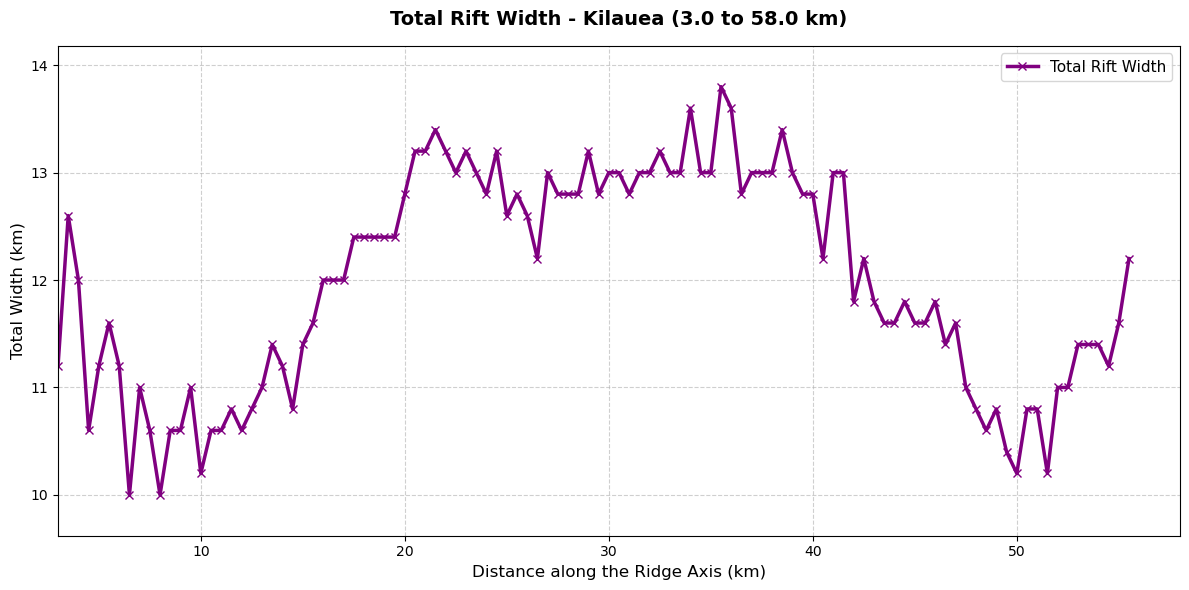

In [6]:
# =============================================================================
# CONFIGURATION PANEL: ZOOM & DESIGN (Modify as needed)
# =============================================================================
K_COLOR_TOTAL_WIDTH = "purple" # Distinct deep earthy tone for Kilauea total width

# =============================================================================
# TOTAL WIDTH PLOT ENGINE
# =============================================================================
plt.figure(figsize=(12, 6))

# Calculate the Total Rift Width by adding both sides together (converted to km)
# Note: Since both Side_1_Y and Side_2_Y represent absolute distances from the center,
# we simply add them together.
K_total_width_km = (K_results_df['Side_1_Y'] + K_results_df['Side_2_Y']) / 1000

# Plot line for the Total Rift Width using explicit cross (x) markers
plt.plot(K_x_in_km, K_total_width_km, 
         color=K_COLOR_TOTAL_WIDTH, marker='x', linestyle='-', linewidth=2.5, 
         label="Total Rift Width")

# Graphical customization, titles, and labels
plt.title(f"Total Rift Width - {K_ISLAND} ({K_START_DIST_KM} to {K_END_DIST_KM} km)", 
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Distance along the Ridge Axis (km)", fontsize=12)
plt.ylabel("Total Width (km)", fontsize=12)

# Set horizontal zoom limits
plt.xlim(K_START_DIST_KM, K_END_DIST_KM)

# Force Y-axis to dynamically auto-scale based ONLY on the visible zoomed data
K_visible_data_total = K_results_df[(K_x_in_km >= K_START_DIST_KM) & (K_x_in_km <= K_END_DIST_KM)]
if not K_visible_data_total.empty:
    # Calculate local min/max for the total width inside the zoom window
    K_visible_total_width = (K_visible_data_total['Side_1_Y'] + K_visible_data_total['Side_2_Y']) / 1000
    K_y_min_total, K_y_max_total = K_visible_total_width.min(), K_visible_total_width.max()
    
    # Add a small 10% padding buffer so points don't clip against edges
    K_padding_total = (K_y_max_total - K_y_min_total) * 0.1 if K_y_max_total != K_y_min_total else 1.0
    plt.ylim(K_y_min_total - K_padding_total, K_y_max_total + K_padding_total)

# Grid setup and legend placement
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11, loc='upper right')

plt.tight_layout()
plt.savefig(f"Total_Rift_Width_{K_ISLAND}.png", dpi=300, bbox_inches='tight')
plt.show()

# Comparaison (apply offset to compare geometries)

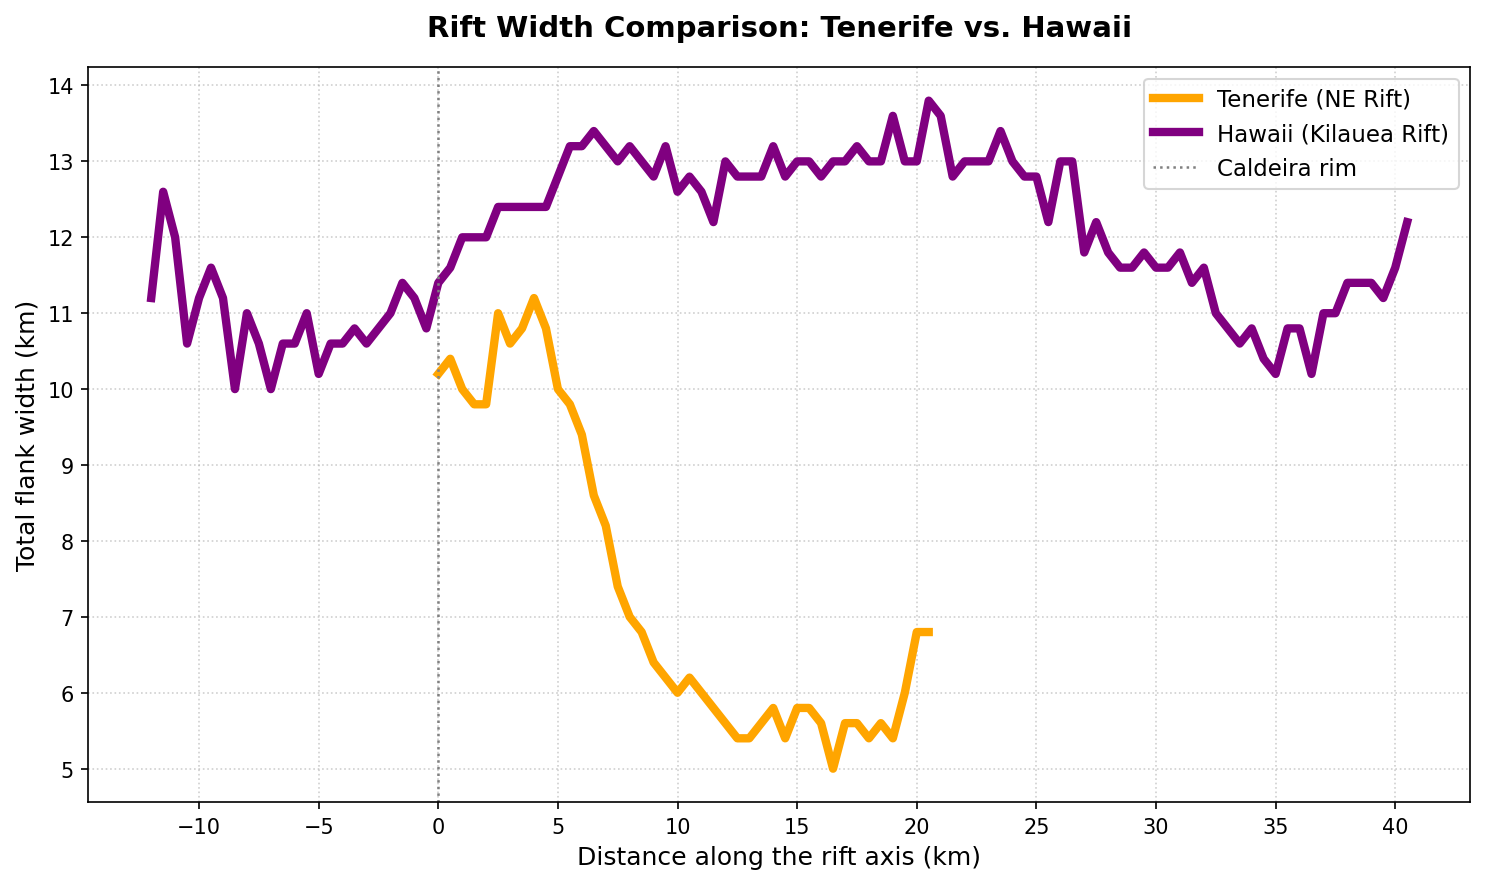

In [7]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker  # Added to control grid line frequency
import numpy as np

# ==========================================
#         CUSTOMIZATION CONFIGURATION
# ==========================================
# Set your axis limits here. Set to None if you want matplotlib to auto-scale.
X_LIMIT_MIN = None    # Starts at -30 km
X_LIMIT_MAX = None     # Ends at 20 km

Y_LIMIT_MIN = None   # None means it will adjust automatically to your data min
Y_LIMIT_MAX = None     # Ends at 16 km

# Grid line spacing customization
Y_GRID_SPACING = 1   # Adds a grid line every 1 km on the y-axis
X_GRID_SPACING = 5   # Adds a grid line every 5 km on the x-axis (adjust as preferred)
# ==========================================

# 1. Filter Tenerife Data to the focus area
T_mask = (T_x_in_km >= T_START_DIST_KM) & (T_x_in_km <= T_END_DIST_KM)
T_x_filtered = T_x_in_km[T_mask]
T_width_filtered = T_total_width_km[T_mask]

# 2. Filter Hawaii Data to the focus area
K_mask = (K_x_in_km >= K_START_DIST_KM) & (K_x_in_km <= K_END_DIST_KM)
K_x_filtered = K_x_in_km[K_mask]
K_width_filtered = K_total_width_km[K_mask]

# 3. Apply the offset calculation to the filtered Hawaii x-axis
# Kilometer 20 becomes point 0
K_x_shifted = K_x_filtered - 15
T_x_shifted = T_x_filtered

# 4. Figure Configuration
plt.figure(figsize=(10, 6), dpi=150)

# 5. Plotting both filtered lines with their respective colors
plt.plot(
    T_x_shifted, 
    T_width_filtered, 
    color=T_COLOR_TOTAL_WIDTH, 
    linewidth=4, 
    label="Tenerife (NE Rift)"
)

plt.plot(
    K_x_shifted, 
    K_width_filtered, 
    color=K_COLOR_TOTAL_WIDTH, 
    linewidth=4, 
    label="Hawaii (Kilauea Rift)"
)

# 6. Applying Custom Limits (only if they are not set to None)
if X_LIMIT_MIN is not None or X_LIMIT_MAX is not None:
    plt.xlim(X_LIMIT_MIN, X_LIMIT_MAX)

if Y_LIMIT_MIN is not None or Y_LIMIT_MAX is not None:
    plt.ylim(Y_LIMIT_MIN, Y_LIMIT_MAX)

# 7. Chart Dressing (Labels, Grid, Legend, and Tickers)
ax = plt.gca()  # Gets the current active axis to apply grid adjustments

# Set the grid spacing frequency based on the configuration above
if Y_GRID_SPACING is not None:
    ax.yaxis.set_major_locator(ticker.MultipleLocator(Y_GRID_SPACING))
if X_GRID_SPACING is not None:
    ax.xaxis.set_major_locator(ticker.MultipleLocator(X_GRID_SPACING))

plt.title("Rift Width Comparison: Tenerife vs. Hawaii", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Distance along the rift axis (km)", fontsize=12)
plt.ylabel("Total flank width (km)", fontsize=12)

# Vertical reference line at x=0 to highlight the alignment point
plt.axvline(x=0, color='grey', linestyle=':', linewidth=1.2, label="Caldeira rim")

plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc="upper right", fontsize=11)

# Layout adjustment to prevent labels from being cut off
plt.tight_layout()

# 8. Save the combined plot
plt.savefig("Combined_Rift_Width_Comparison2.png", dpi=300)
plt.show()

# Comparaison (NORMALIZED to compare geometries)

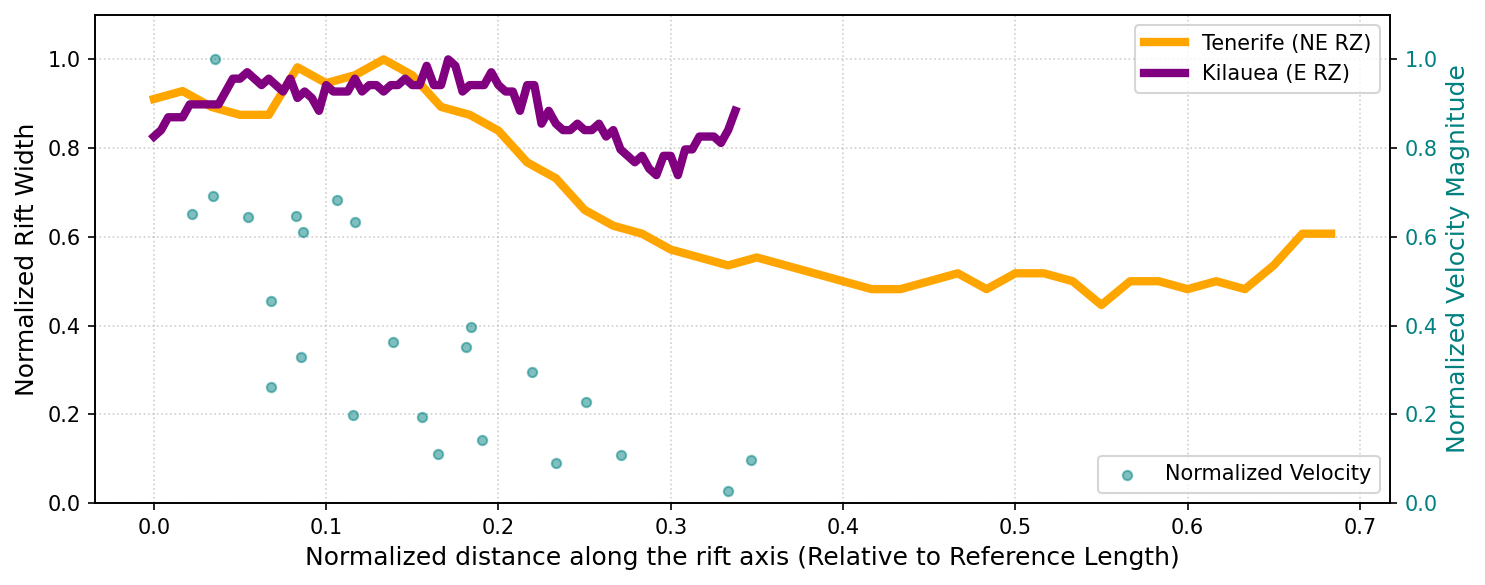

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# =============================================================================
# DATA PROCESSING & NORMALIZATION
# =============================================================================

# 1. Filter and Offset for Tenerife
T_mask = (T_x_in_km >= T_START_DIST_KM) & (T_x_in_km <= T_END_DIST_KM)
T_x = T_x_in_km[T_mask]
T_y = T_total_width_km[T_mask]

# 2. Filter and Offset for Hawaii (with suppression of X < 0)
K_mask = (K_x_in_km >= K_START_DIST_KM) & (K_x_in_km <= K_END_DIST_KM)
K_x_shifted = K_x_in_km[K_mask] - 15
K_y = K_total_width_km[K_mask]

K_pos_mask = (K_x_shifted >= 0)
K_x = K_x_shifted[K_pos_mask]
K_y = K_y[K_pos_mask]

# 3. Load and Normalize Velocities
csv_file_path = "Velocities_projected.csv"
v_df = pd.read_csv(csv_file_path)

# Normalize Velocity Y: divided by its max value
v_y_norm = v_df["magnitude"] / v_df["magnitude"].max()

# Normalize Velocity X: divided by the 120km reference scale
v_x_norm = v_df["distance_offset"] / 120

# 4. NORMALIZATION (Width & Distance)
# Y (Width): Normalized by the local maximum of each dataset
T_y_norm = T_y / T_y.max()
K_y_norm = K_y / K_y.max()

# X (Distance): Normalized by their respective reference lengths (30km / 120km)
T_x_norm = T_x / 30
K_x_norm = K_x / 120

# =============================================================================
# PLOTTING
# =============================================================================
fig, ax1 = plt.subplots(figsize=(10, 4), dpi=150)

# Plot normalized rift widths
ax1.plot(T_x_norm, T_y_norm, color=T_COLOR_TOTAL_WIDTH, linewidth=4, label="Tenerife (NE RZ)")
ax1.plot(K_x_norm, K_y_norm, color=K_COLOR_TOTAL_WIDTH, linewidth=4, label="Kilauea (E RZ)")

# Set Left Axis labels
ax1.set_ylim(0, 1.1)
ax1.set_xlabel("Normalized distance along the rift axis (Relative to Reference Length)", fontsize=12)
ax1.set_ylabel("Normalized Rift Width", fontsize=12)

# Create Secondary Axis for Velocity
ax2 = ax1.twinx()
# Plotting velocity with normalized X (120km scale) and Y (Max magnitude)
ax2.scatter(v_x_norm, v_y_norm, color="teal", alpha=0.5, s=20, label="Normalized Velocity")
ax2.set_ylabel("Normalized Velocity Magnitude", color="teal", fontsize=12)
ax2.tick_params(axis='y', labelcolor="teal")
ax2.set_ylim(0, 1.1)

# Final Polish
#plt.title("Normalized Rift Width & Velocity Comparison", fontsize=14, fontweight='bold')
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(loc="upper right")
ax2.legend(loc="lower right")

plt.tight_layout()
plt.savefig("Normalized_Width_And_Velocity_Comparison.png", dpi=300)
plt.show()

# Flank Displacement along the rift

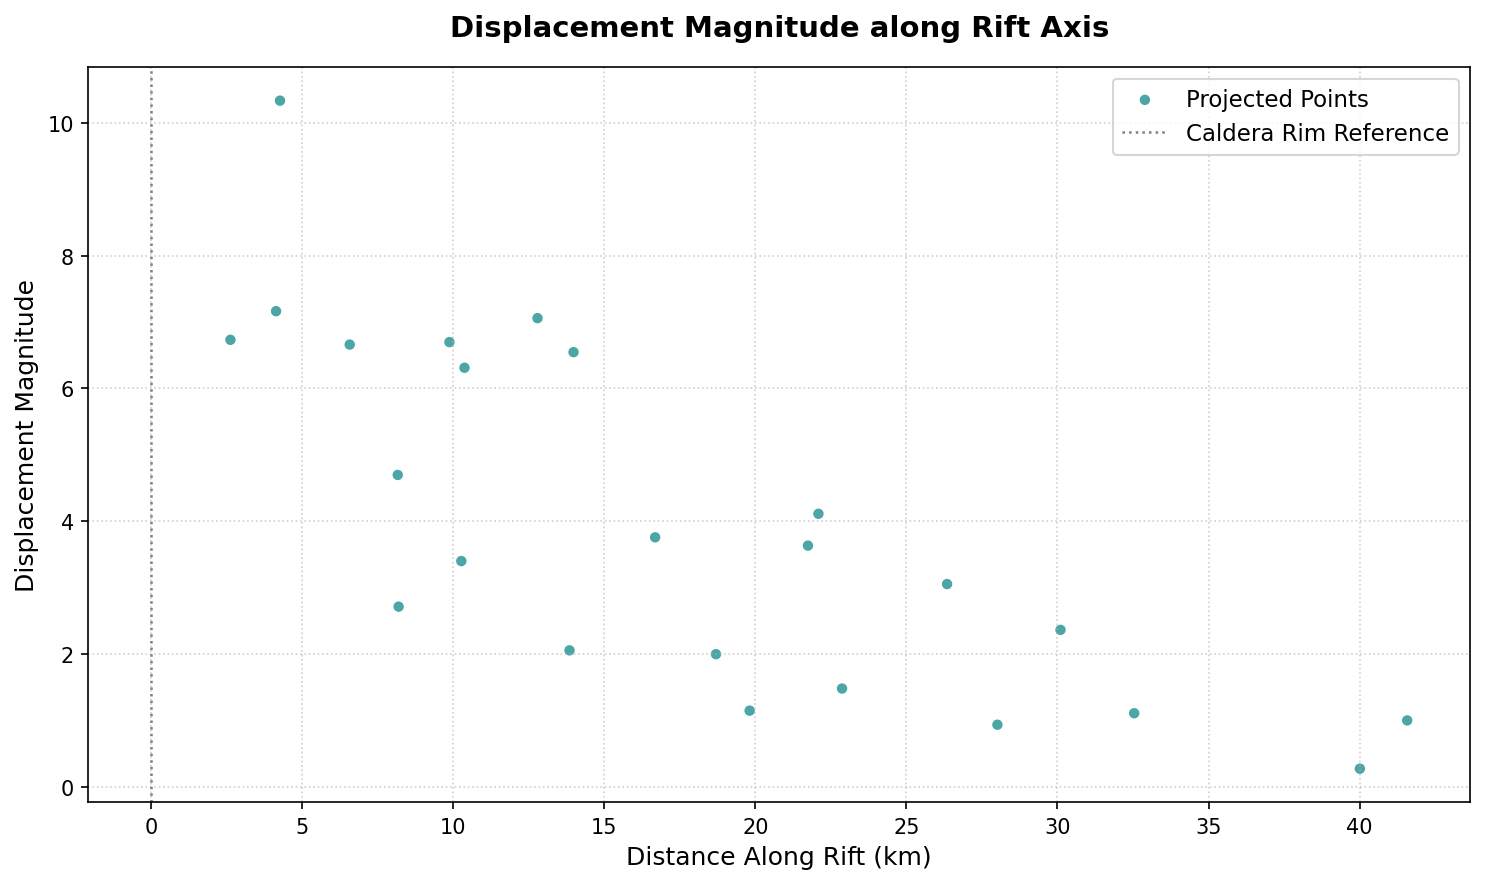

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ==========================================
#         CUSTOMIZATION CONFIGURATION
# ==========================================
# Set your axis limits here if needed. Set to None for automatic scaling.
X_LIMIT_MIN = None    # Distance axis min
X_LIMIT_MAX = None    # Distance axis max

Y_LIMIT_MIN = None    # Magnitude axis min
Y_LIMIT_MAX = None    # Magnitude axis max

# Grid line spacing customization
X_GRID_SPACING = 5     # Adds a grid line every 5 km on the distance axis
Y_GRID_SPACING = None  # Change to a number to force specific magnitude grid spacing
# ==========================================

# 1. Load the projected velocities CSV file
csv_file_path = "Velocities_projected.csv"
df = pd.read_csv(csv_file_path)

# 2. Extract columns for plotting (Swapped as requested)
x_data = df["distance_offset"]
y_data = df["magnitude"]

# 3. Figure Configuration
plt.figure(figsize=(10, 6), dpi=150)

# 4. Plotting the data
plt.scatter(
    x_data, 
    y_data, 
    color="teal",        # Clean, professional color choice
    alpha=0.7,           # Slight transparency to see overlapping points clearly
    edgecolors="none", 
    s=25,                # Marker size
    label="Projected Points"
)

# 5. Applying Custom Limits (only if they are not set to None)
if X_LIMIT_MIN is not None or X_LIMIT_MAX is not None:
    plt.xlim(X_LIMIT_MIN, X_LIMIT_MAX)

if Y_LIMIT_MIN is not None or Y_LIMIT_MAX is not None:
    plt.ylim(Y_LIMIT_MIN, Y_LIMIT_MAX)

# 6. Chart Dressing (Labels, Grid, Legend, and Tickers)
ax = plt.gca()

if X_GRID_SPACING is not None:
    ax.xaxis.set_major_locator(ticker.MultipleLocator(X_GRID_SPACING))
if Y_GRID_SPACING is not None:
    ax.yaxis.set_major_locator(ticker.MultipleLocator(Y_GRID_SPACING))

plt.title("Displacement Magnitude along Rift Axis", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Distance Along Rift (km)", fontsize=12)
plt.ylabel("Displacement Magnitude", fontsize=12)

# Vertical anchor line at X=0 to mark your alignment reference (e.g., caldera rim)
plt.axvline(x=0, color='grey', linestyle=':', linewidth=1.2, label="Caldera Rim Reference")

plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc="upper right", fontsize=11)

# Layout adjustment to prevent labels from being cut off
plt.tight_layout()

# 7. Save and display the plot
plt.savefig("Velocity_Magnitude_vs_Distance.png", dpi=300)
plt.show()

# All informations

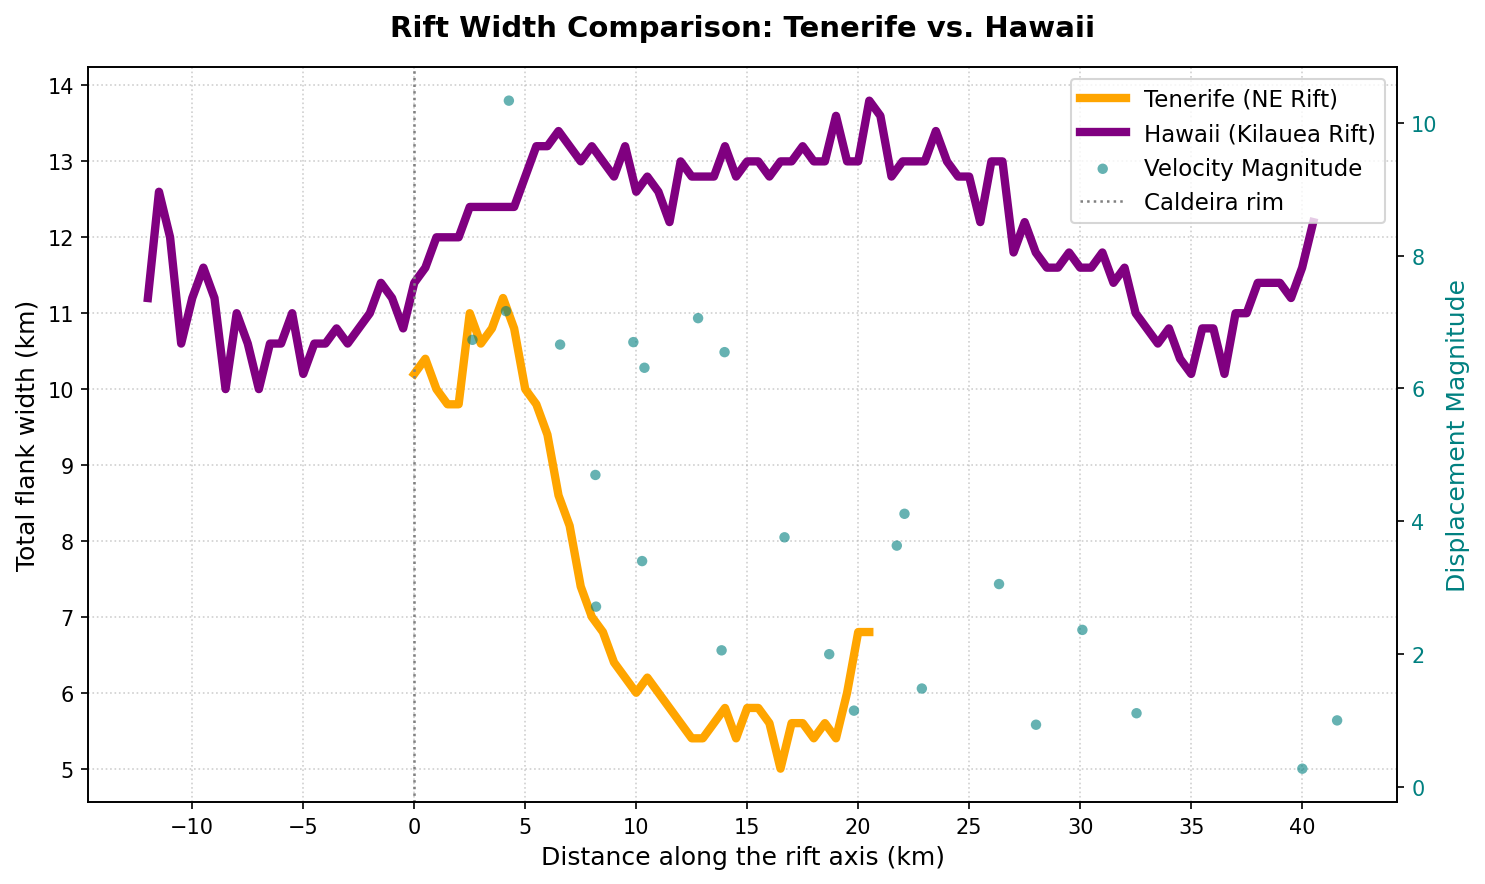

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker  # Added to control grid line frequency
import numpy as np

# ==========================================
#         CUSTOMIZATION CONFIGURATION
# ==========================================
# Set your axis limits here. Set to None if you want matplotlib to auto-scale.
X_LIMIT_MIN = None    # Starts at -30 km
X_LIMIT_MAX = None     # Ends at 20 km

Y_LIMIT_MIN = None   # None means it will adjust automatically to your data min
Y_LIMIT_MAX = None     # Ends at 16 km

Y_RIGHT_LIMIT_MIN = None  # Right Y-axis (Magnitude) min
Y_RIGHT_LIMIT_MAX = None  # Right Y-axis (Magnitude) max

# Grid line spacing customization
Y_GRID_SPACING = 1   # Adds a grid line every 1 km on the left y-axis
X_GRID_SPACING = 5   # Adds a grid line every 5 km on the x-axis (adjust as preferred)
Y_RIGHT_GRID_SPACING = None # Set to a number to force specific right y-axis grid lines
# ==========================================

# 1. Load the projected velocities CSV file for the right Y-axis
csv_file_path = "Velocities_projected.csv"
df = pd.read_csv(csv_file_path)
v_x_data = df["distance_offset"]
v_y_data = df["magnitude"]

# 2. Filter Tenerife Data to the focus area
T_mask = (T_x_in_km >= T_START_DIST_KM) & (T_x_in_km <= T_END_DIST_KM)
T_x_filtered = T_x_in_km[T_mask]
T_width_filtered = T_total_width_km[T_mask]

# 3. Filter Hawaii Data to the focus area
K_mask = (K_x_in_km >= K_START_DIST_KM) & (K_x_in_km <= K_END_DIST_KM)
K_x_filtered = K_x_in_km[K_mask]
K_width_filtered = K_total_width_km[K_mask]

# 4. Apply the offset calculation to the filtered Hawaii x-axis
# Kilometer 15 becomes point 0
K_x_shifted = K_x_filtered - 15
T_x_shifted = T_x_filtered

# 5. Figure Configuration
fig, ax1 = plt.subplots(figsize=(10, 6), dpi=150)

# Track all plot components for a unified legend box
plot_elements = []

# 6. Plotting both filtered lines with their respective colors (Left Y-Axis)
line1 = ax1.plot(
    T_x_shifted, 
    T_width_filtered, 
    color=T_COLOR_TOTAL_WIDTH, 
    linewidth=4, 
    label="Tenerife (NE Rift)"
)

line2 = ax1.plot(
    K_x_shifted, 
    K_width_filtered, 
    color=K_COLOR_TOTAL_WIDTH, 
    linewidth=4, 
    label="Hawaii (Kilauea Rift)"
)
plot_elements += line1 + line2

# 7. Create the Right Y-Axis and plot the velocity scatter data
ax2 = ax1.twinx()
scatter = ax2.scatter(
    v_x_data,
    v_y_data,
    color="teal",
    alpha=0.6,
    edgecolors="none",
    s=25,
    label="Velocity Magnitude"
)
plot_elements.append(scatter)

# 8. Applying Custom Limits (only if they are not set to None)
if X_LIMIT_MIN is not None or X_LIMIT_MAX is not None:
    plt.xlim(X_LIMIT_MIN, X_LIMIT_MAX)

if Y_LIMIT_MIN is not None or Y_LIMIT_MAX is not None:
    ax1.set_ylim(Y_LIMIT_MIN, Y_LIMIT_MAX)

if Y_RIGHT_LIMIT_MIN is not None or Y_RIGHT_LIMIT_MAX is not None:
    ax2.set_ylim(Y_RIGHT_LIMIT_MIN, Y_RIGHT_LIMIT_MAX)

# 9. Chart Dressing (Labels, Grid, Legend, and Tickers)
# Set the grid spacing frequency based on the configuration above
if Y_GRID_SPACING is not None:
    ax1.yaxis.set_major_locator(ticker.MultipleLocator(Y_GRID_SPACING))
if X_GRID_SPACING is not None:
    ax1.xaxis.set_major_locator(ticker.MultipleLocator(X_GRID_SPACING))
if Y_RIGHT_GRID_SPACING is not None:
    ax2.yaxis.set_major_locator(ticker.MultipleLocator(Y_RIGHT_GRID_SPACING))

ax1.set_title("Rift Width Comparison: Tenerife vs. Hawaii", fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel("Distance along the rift axis (km)", fontsize=12)
ax1.set_ylabel("Total flank width (km)", fontsize=12)
ax2.set_ylabel("Displacement Magnitude", color="teal", fontsize=12)

# Match right Y-axis tick mark colors to the teal scatter points
ax2.tick_params(axis='y', labelcolor="teal")

# Vertical reference line at x=0 to highlight the alignment point
ref_line = ax1.axvline(x=0, color='grey', linestyle=':', linewidth=1.2, label="Caldeira rim")
plot_elements.append(ref_line)

# Generate a single unified legend box
labels = [e.get_label() for e in plot_elements]
ax1.legend(plot_elements, labels, loc="upper right", fontsize=11)

ax1.grid(True, linestyle=':', alpha=0.6)

# Layout adjustment to prevent labels from being cut off
plt.tight_layout()

# 10. Save the combined plot
plt.savefig("Combined_Rift_Width_Comparison2.png", dpi=300)
plt.show()

# Gradient value

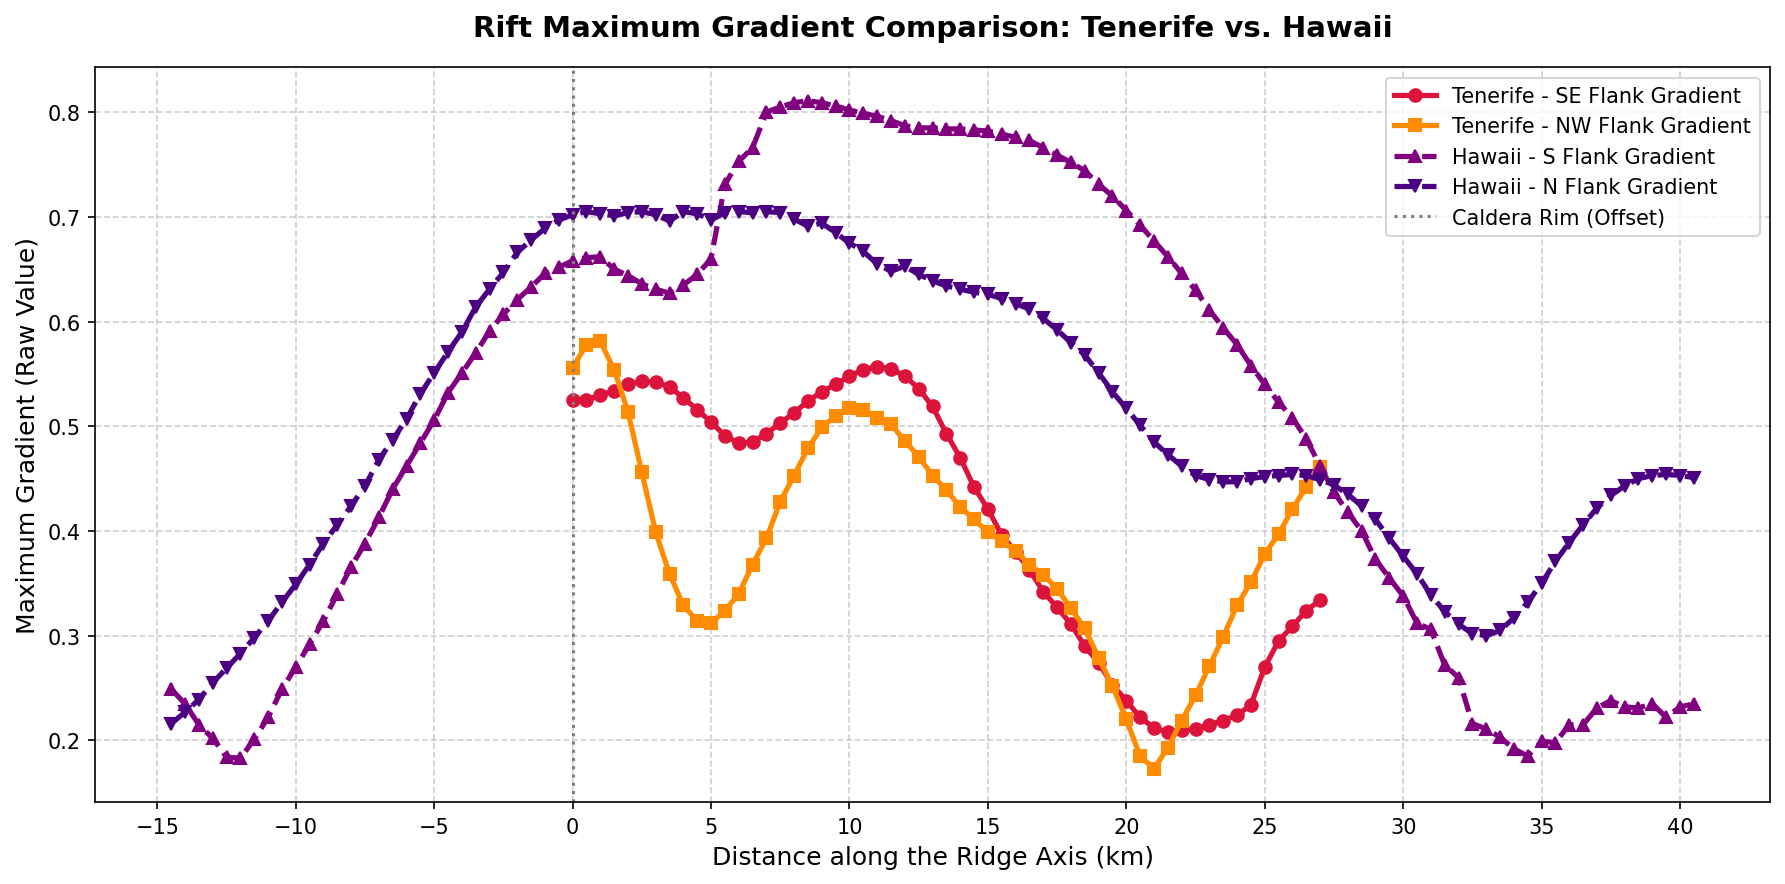

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# =============================================================================
# 1. CONFIGURATION PANEL - TENERIFE
# =============================================================================
T_CSV_PATH = "Gradient_Tenerife.csv"
T_ISLAND = "Tenerife"

T_COL_ALONG_RIDGE = "distance"       
T_COL_VERTEX_IDX = "vertex_index"    
T_COL_GRADIENT = "gradient"          

T_SIDE_1_MIN_IDX, T_SIDE_1_MAX_IDX = 0, 50
T_SIDE_2_MIN_IDX, T_SIDE_2_MAX_IDX = 51, 101

T_COLOR_SIDE_1 = "crimson"  # SE Flank
T_COLOR_SIDE_2 = "darkorange"  # NW Flank

# =============================================================================
# 2. CONFIGURATION PANEL - KILAUEA (HAWAII)
# =============================================================================
K_CSV_PATH = "Gradient_Kilauea.csv" 
K_ISLAND = "Hawaii"

K_COL_ALONG_RIDGE = "distance"       
K_COL_VERTEX_IDX = "vertex_index"    
K_COL_GRADIENT = "gradient"          

K_SIDE_1_MIN_IDX, K_SIDE_1_MAX_IDX = 0, 50   
K_SIDE_2_MIN_IDX, K_SIDE_2_MAX_IDX = 51, 101 

K_COLOR_SIDE_1 = "purple"    # SE Flank
K_COLOR_SIDE_2 = "indigo"   # NW Flank

# =============================================================================
# DATA PROCESSING ENGINE - TENERIFE
# =============================================================================
T_df = pd.read_csv(T_CSV_PATH)
T_along_ridge_x = []
T_side_1_grad = []
T_side_2_grad = []

T_grouped = T_df.groupby(T_COL_ALONG_RIDGE)

for T_x_val, T_group in T_grouped:
    T_along_ridge_x.append(T_x_val)
    
    # --- SIDE 1 (Southeast) ---
    T_side_1_filter = (T_group[T_COL_VERTEX_IDX] >= T_SIDE_1_MIN_IDX) & (T_group[T_COL_VERTEX_IDX] <= T_SIDE_1_MAX_IDX)
    T_group_side_1 = T_group[T_side_1_filter]
    if not T_group_side_1.empty:
        T_max_row_idx_1 = T_group_side_1[T_COL_GRADIENT].idxmax()
        T_side_1_grad.append(T_group_side_1.loc[T_max_row_idx_1, T_COL_GRADIENT])
    else:
        T_side_1_grad.append(None)

    # --- SIDE 2 (Northwest) ---
    T_side_2_filter = (T_group[T_COL_VERTEX_IDX] >= T_SIDE_2_MIN_IDX) & (T_group[T_COL_VERTEX_IDX] <= T_SIDE_2_MAX_IDX)
    T_group_side_2 = T_group[T_side_2_filter]
    if not T_group_side_2.empty:
        T_max_row_idx_2 = T_group_side_2[T_COL_GRADIENT].idxmax()
        T_side_2_grad.append(T_group_side_2.loc[T_max_row_idx_2, T_COL_GRADIENT])
    else:
        T_side_2_grad.append(None)

T_results_df = pd.DataFrame({
    'Along_Ridge_X': T_along_ridge_x,
    'Side_1_Grad': T_side_1_grad,
    'Side_2_Grad': T_side_2_grad
}).sort_values(by='Along_Ridge_X')

T_x_in_km = T_results_df['Along_Ridge_X'] / 1000

# =============================================================================
# DATA PROCESSING ENGINE - KILAUEA (HAWAII)
# =============================================================================
K_df = pd.read_csv(K_CSV_PATH)
K_along_ridge_x = []
K_side_1_grad = []
K_side_2_grad = []

K_grouped = K_df.groupby(K_COL_ALONG_RIDGE)

for K_x_val, K_group in K_grouped:
    K_along_ridge_x.append(K_x_val)
    
    # --- SIDE 1 ---
    K_side_1_filter = (K_group[K_COL_VERTEX_IDX] >= K_SIDE_1_MIN_IDX) & (K_group[K_COL_VERTEX_IDX] <= K_SIDE_1_MAX_IDX)
    K_group_side_1 = K_group[K_side_1_filter]
    if not K_group_side_1.empty:
        K_max_row_idx_1 = K_group_side_1[K_COL_GRADIENT].idxmax()
        K_side_1_grad.append(K_group_side_1.loc[K_max_row_idx_1, K_COL_GRADIENT])
    else:
        K_side_1_grad.append(None)

    # --- SIDE 2 ---
    K_side_2_filter = (K_group[K_COL_VERTEX_IDX] >= K_SIDE_2_MIN_IDX) & (K_group[K_COL_VERTEX_IDX] <= K_SIDE_2_MAX_IDX)
    K_group_side_2 = K_group[K_side_2_filter]
    if not K_group_side_2.empty:
        K_max_row_idx_2 = K_group_side_2[K_COL_GRADIENT].idxmax()
        K_side_2_grad.append(K_group_side_2.loc[K_max_row_idx_2, K_COL_GRADIENT])
    else:
        K_side_2_grad.append(None)

K_results_df = pd.DataFrame({
    'Along_Ridge_X': K_along_ridge_x,
    'Side_1_Grad': K_side_1_grad,
    'Side_2_Grad': K_side_2_grad
}).sort_values(by='Along_Ridge_X')

# Convert to KM and apply the exact -15 km structural offset for Hawaii
K_x_shifted = (K_results_df['Along_Ridge_X'] / 1000) - 15

# =============================================================================
# PLOTTING ENGINE (Single Axis)
# =============================================================================
fig, ax1 = plt.subplots(figsize=(12, 6), dpi=150)
plot_elements = []

# --- Tenerife Lines ---
t_line1 = ax1.plot(T_x_in_km, T_results_df['Side_1_Grad'], color=T_COLOR_SIDE_1, 
                   marker='o', linestyle='-', linewidth=2.5, label="Tenerife - SE Flank Gradient")
t_line2 = ax1.plot(T_x_in_km, T_results_df['Side_2_Grad'], color=T_COLOR_SIDE_2, 
                   marker='s', linestyle='-', linewidth=2.5, label="Tenerife - NW Flank Gradient")

# --- Hawaii Lines (Shifted X) ---
k_line1 = ax1.plot(K_x_shifted, K_results_df['Side_1_Grad'], color=K_COLOR_SIDE_1, 
                   marker='^', linestyle='--', linewidth=2.5, label="Hawaii - S Flank Gradient")
k_line2 = ax1.plot(K_x_shifted, K_results_df['Side_2_Grad'], color=K_COLOR_SIDE_2, 
                   marker='v', linestyle='--', linewidth=2.5, label="Hawaii - N Flank Gradient")

plot_elements += t_line1 + t_line2 + k_line1 + k_line2

ax1.set_xlabel("Distance along the Ridge Axis (km)", fontsize=12)
ax1.set_ylabel("Maximum Gradient (Raw Value)", fontsize=12)

# --- Visual Dressing & Grid ---
ax1.xaxis.set_major_locator(ticker.MultipleLocator(5))  # Tick mark every 5 km
ref_line = ax1.axvline(x=0, color='grey', linestyle=':', linewidth=1.5, label="Caldera Rim (Offset)")
plot_elements.append(ref_line)

# Single Unified Legend Box
labels = [e.get_label() for e in plot_elements]
ax1.legend(plot_elements, labels, loc="upper right", fontsize=10)

ax1.grid(True, linestyle='--', alpha=0.6)
plt.title("Rift Maximum Gradient Comparison: Tenerife vs. Hawaii", fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()

# Save standalone structural profile product
plt.savefig("Combined_Rift_Gradients_Comparison.png", dpi=300, bbox_inches='tight')
plt.show()